# Télécharge votre tranche des comptages routiers permanents de la Ville de Paris.


1. Remplacez ROUTES par vos 3 axes (noms exacts de la colonne `axe` de liste_des_axes.csv).
2. Lancez : python download_data.py
3. Les données arrivent dans data/raw/comptages.csv (dossier ignoré par Git).

Source : https://opendata.paris.fr/explore/dataset/comptages-routiers-permanents/



In [3]:
from pathlib import Path
import requests
import pandas as pd

/Users/schneider_thalerant/Master DM/Analyse et transformation des données/projet-trafic-paris/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
ROUTES = ["Lecourbe", "Av_Foch", "Av_Daumesnil"]  # ex. ["Pyrenees", "Av_de_Clichy", "Voie_Mazas"]
DATE_DEBUT = "2026-03-01"
DATE_FIN = "2026-09-01"  # exclue

In [4]:
URL = ("https://opendata.paris.fr/api/explore/v2.1/catalog/datasets/"
       "comptages-routiers-permanents/exports/csv")
COLONNES = ("iu_ac,libelle,t_1h,q,k,etat_trafic,iu_nd_amont,libelle_nd_amont,"
            "iu_nd_aval,libelle_nd_aval,etat_barre")
SORTIE = Path("/Users/schneider_thalerant/Master DM/Analyse et transformation des données/projet-trafic-paris") / "data" / "comptages_trafic.csv"

CHEMIN = "/Users/schneider_thalerant/Master DM/Analyse et transformation des données/projet-trafic-paris/data/comptages_trafic.csv"


In [15]:
def main():
    if len(ROUTES) != 3:
        raise SystemExit("Renseignez vos 3 axes dans ROUTES avant de lancer le script.")
    axes = ",".join(f"'{r}'" for r in ROUTES)
    params = {
        "select": COLONNES,
        "where": f"libelle in ({axes}) and t_1h >= date'{DATE_DEBUT}' and t_1h < date'{DATE_FIN}'",
    }
    SORTIE.parent.mkdir(parents=True, exist_ok=True)
    print("Téléchargement en cours (1 à 3 minutes)...")
    with requests.get(URL, params=params, stream=True, timeout=600) as r:
        r.raise_for_status()
        with open(SORTIE, "wb") as f:
            for chunk in r.iter_content(1 << 20):
                f.write(chunk)
    taille = SORTIE.stat().st_size / 1e6
    if taille < 0.01:
        raise SystemExit("Fichier vide : vérifiez l'orthographe de vos axes dans ROUTES.")
    print(f"{SORTIE} : {taille:.1f} Mo")

if __name__ == "__main__": 
    main()
    

Téléchargement en cours (1 à 3 minutes)...
/Users/schneider_thalerant/Master DM/Analyse et transformation des données/projet-trafic-paris/data/comptages_trafic.csv : 23.8 Mo


In [5]:
TYPES = {
    "iu_ac": "string", "iu_nd_amont": "string", "iu_nd_aval": "string",
    "libelle": "category", "etat_trafic": "category", "etat_barre": "category",
}

morceaux = []
for i, chunk in enumerate(pd.read_csv(CHEMIN, sep=";", encoding="utf-8-sig",
                                      dtype=TYPES, chunksize=50_000)):
    morceaux.append(chunk)
print(f"{i + 1} chunks lus")

df = pd.concat(morceaux, ignore_index=True)


5 chunks lus


In [6]:
df.shape

(200744, 11)

In [7]:
df.head()

,iu_ac,libelle,t_1h,q,k,etat_trafic,iu_nd_amont,libelle_nd_amont,iu_nd_aval,libelle_nd_aval,etat_barre
0,5582,Lecourbe,2026-08-31T23:00:00+00:00,198.0,NaN,Inconnu,2932,Lecourbe-Volontaires,2933,Lecourbe-Cambronne,Ouvert
1,5584,Lecourbe,2026-08-31T23:00:00+00:00,198.0,0.82722,Fluide,2934,Lecourbe-Roussin,2935,Lecourbe-Seche-Peclet,Ouvert
2,4383,Av_Foch,2026-08-31T23:00:00+00:00,145.0,0.40667,Fluide,2351,Foch-Pergolese,2347,Av_Foch-Av_Malakoff,Ouvert
3,4384,Av_Foch,2026-08-31T23:00:00+00:00,464.0,3.03556,Fluide,2351,Foch-Pergolese,2352,Pte_Dauphine-Foch,Ouvert
4,4385,Av_Foch,2026-08-31T23:00:00+00:00,145.0,1.89667,Fluide,2352,Pte_Dauphine-Foch,2351,Foch-Pergolese,Ouvert


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200744 entries, 0 to 200743
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype   
---  ------            --------------   -----   
 0   iu_ac             200744 non-null  string  
 1   libelle           200744 non-null  category
 2   t_1h              200744 non-null  object  
 3   q                 129679 non-null  float64 
 4   k                 137621 non-null  float64 
 5   etat_trafic       200744 non-null  object  
 6   iu_nd_amont       200744 non-null  string  
 7   libelle_nd_amont  200744 non-null  object  
 8   iu_nd_aval        200744 non-null  string  
 9   libelle_nd_aval   200744 non-null  object  
 10  etat_barre        200744 non-null  object  
dtypes: category(1), float64(2), object(5), string(3)
memory usage: 15.5+ MB


In [9]:
df.dtypes

iu_ac               string[python]
libelle                   category
t_1h                        object
q                          float64
k                          float64
etat_trafic                 object
iu_nd_amont         string[python]
libelle_nd_amont            object
iu_nd_aval          string[python]
libelle_nd_aval             object
etat_barre                  object
dtype: object

In [10]:
df.isnull().sum()

iu_ac                   0
libelle                 0
t_1h                    0
q                   71065
k                   63123
etat_trafic             0
iu_nd_amont             0
libelle_nd_amont        0
iu_nd_aval              0
libelle_nd_aval         0
etat_barre              0
dtype: int64

In [11]:
print(f"Il y a {len(df.dropna())} lignes sans valeurs manquantes sur {len(df)} lignes au total. Soit {len(df.dropna()) / len(df) * 100:.1f}% de lignes complètes.")

Il y a 100396 lignes sans valeurs manquantes sur 200744 lignes au total. Soit 50.0% de lignes complètes.


In [13]:
df_clean = df.dropna()

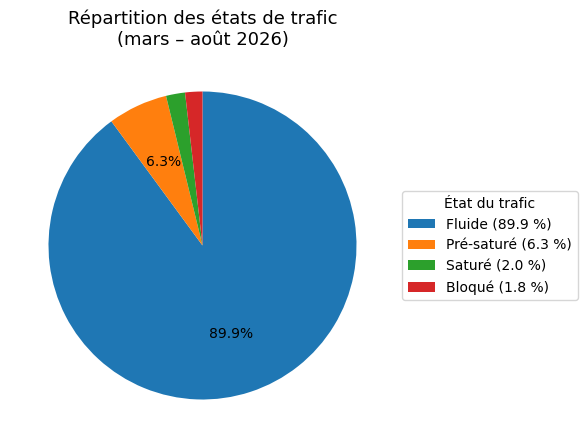

In [ ]:
import matplotlib.pyplot as plt

counts = df_clean["etat_trafic"].value_counts()
pct = counts / counts.sum() * 100

ax = counts.plot.pie(
    figsize=(7, 5),
    autopct=lambda p: f"{p:.1f}%" if p >= 5 else "", 
    labels=None,
    ylabel="",
    startangle=90,
    counterclock=False,
)
ax.set_title("Répartition des états de trafic\n(mars – août 2026)", fontsize=13)
ax.legend(
    [f"{etat} ({p:.1f} %)" for etat, p in pct.items()],
    title="État du trafic",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
)
plt.show()


libelle
Av_Foch         626.580138
Lecourbe        396.503409
Av_Daumesnil    171.226677
Name: q, dtype: float64


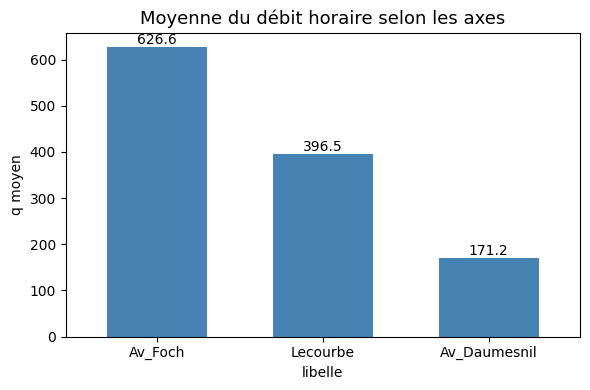

In [22]:
import matplotlib.pyplot as plt

VAR_CAT = "libelle"   # la variable à 3 modalités
VAR_NUM = "q"   # la variable quantitative

moyennes = (
    df_clean.groupby(VAR_CAT, observed=True)[VAR_NUM]
    .mean()
    .sort_values(ascending=False)
)
print(moyennes)

ax = moyennes.plot.bar(figsize=(6, 4), color="steelblue", width=0.6)

ax.set_title(f"Moyenne du débit horaire selon les axes", fontsize=13)
ax.set_xlabel(VAR_CAT)
ax.set_ylabel(f"{VAR_NUM} moyen")
ax.bar_label(ax.containers[0], fmt="%.1f")   # affiche la valeur au-dessus de chaque barre
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
